# Chapter 12: Multilevel linear models — the basics

Reproducing examples and exercises from Gelman & Hill (2007),
*Data Analysis Using Regression and Multilevel/Hierarchical Models*,
Chapter 12, using the **interlace** package.

All results are verified against R `lme4::lmer()` reference fixtures.

**Dataset:** Minnesota household radon measurements (EPA SRRS-II survey).
Radon is a naturally occurring radioactive gas that is the second-leading
cause of lung cancer. 919 measurements across 85 Minnesota counties.

**Key question:** What is the radon level in a given house, given which
floor the measurement was taken on and the county's underlying geology
(uranium content)?

| Model | Formula | Section |
|-------|---------|--------|
| M0 | `y ~ 1 + (1 \| county)` | 12.4 |
| M1 | `y ~ x + (1 \| county)` | 12.4 |
| M2 | `y ~ x + u + (1 \| county)` | 12.6 |

In [1]:
import json
import numpy as np
import pandas as pd
import interlace
from pathlib import Path
from plotnine import (
    ggplot, aes,
    geom_point, geom_line, geom_abline, geom_hline, geom_vline,
    geom_errorbar, geom_smooth, geom_segment, geom_text,
    facet_wrap, labs, theme_bw, theme, element_text,
    scale_x_log10, scale_x_continuous, scale_y_continuous,
    xlim, ylim, coord_cartesian,
)

# Paths
FIXTURE_DIR = Path("../../tests/fixtures")
DATA_DIR = Path("../applied regression and multilevel modeling/ARM_Data/radon")

## 1. Data preparation

Following the book's R code exactly: filter to Minnesota, compute log radon
(replacing zeros with 0.1), build county indices, and merge county-level
uranium from `cty.dat`.

In [2]:
# Load the pre-cleaned data (generated by gen_gelman_hill_ch12.R)
df = pd.read_csv(FIXTURE_DIR / "gh_ch12_radon_data.csv")
county_df = pd.read_csv(FIXTURE_DIR / "gh_ch12_county_data.csv")

print(f"Observations : {len(df)}")
print(f"Counties     : {df['county'].nunique()}")
print(f"Floor (x)    : {df['x'].value_counts().to_dict()}")
print(f"Log radon    : mean={df['y'].mean():.3f}, sd={df['y'].std():.3f}")
print()
df.head()

Observations : 919
Counties     : 85
Floor (x)    : {0: 766, 1: 153}
Log radon    : mean=1.225, sd=0.853



,y,x,county,county_name,u,log_radon,radon
0,0.788457,1,1,AITKIN,-0.689048,0.788457,2.2
1,0.788457,0,1,AITKIN,-0.689048,0.788457,2.2
2,1.064711,0,1,AITKIN,-0.689048,1.064711,2.9
3,0.000000,0,1,AITKIN,-0.689048,0.000000,1.0
4,1.131402,0,2,ANOKA,-0.847313,1.131402,3.1


In [3]:
# County-level summary
county_summary = (
    df.groupby("county")
    .agg(
        county_name=("county_name", "first"),
        n=("y", "size"),
        mean_y=("y", "mean"),
        sd_y=("y", "std"),
        log_uranium=("u", "first"),
    )
    .reset_index()
)
county_summary["se_y"] = county_summary["sd_y"] / np.sqrt(county_summary["n"])

print(f"County sample sizes: min={county_summary['n'].min()}, "
      f"median={county_summary['n'].median():.0f}, "
      f"max={county_summary['n'].max()}")
print()
county_summary.sort_values("n", ascending=False).head(10)

County sample sizes: min=1, median=5, max=116



,county,county_name,n,mean_y,sd_y,log_uranium,se_y
69,70,ST LOUIS,116,0.768247,0.799897,-0.474674,0.074269
25,26,HENNEPIN,105,1.285096,0.710445,-0.096521,0.069332
18,19,DAKOTA,63,1.292559,0.752302,-0.024145,0.094781
1,2,ANOKA,52,0.833250,0.770284,-0.847313,0.106819
79,80,WASHINGTON,46,1.251200,0.796532,-0.147484,0.117442
60,61,RAMSEY,32,1.091176,0.668074,-0.418054,0.118100
70,71,STEARNS,25,1.376557,0.701825,0.116395,0.140365
53,54,OLMSTED,23,1.212772,0.760543,0.243150,0.158584
13,14,CLAY,14,1.782515,1.010248,0.343781,0.270000
65,66,ROSEAU,14,1.254005,0.681341,-0.212045,0.182096


## 2. Complete pooling and no pooling (Section 12.2–12.3)

Before fitting multilevel models, the book compares two extremes:

- **Complete pooling**: ignore counties entirely — one regression line for all data
- **No pooling**: fit separate intercepts for each county (85 dummy variables)

The multilevel model will be a compromise between these.

In [4]:
import statsmodels.formula.api as smf

# Complete pooling: y ~ x
lm_pooled = smf.ols("y ~ x", data=df).fit()
print("Complete pooling: y ~ x")
print(f"  Intercept = {lm_pooled.params['Intercept']:.3f}")
print(f"  x (floor) = {lm_pooled.params['x']:.3f}")
print()

# No pooling: y ~ x + C(county) - 1  (separate intercept per county)
lm_unpooled = smf.ols("y ~ x + C(county) - 1", data=df).fit()
print("No pooling: y ~ x + C(county) - 1")
print(f"  x (floor) = {lm_unpooled.params['x']:.3f}")
print(f"  County intercepts: {lm_unpooled.params.drop('x').describe().round(3).to_dict()}")

Complete pooling: y ~ x
  Intercept = 1.327
  x (floor) = -0.613

No pooling: y ~ x + C(county) - 1
  x (floor) = -0.721
  County intercepts: {'count': 85.0, 'mean': 1.501, 'std': 0.48, 'min': 0.402, '25%': 1.187, '50%': 1.513, '75%': 1.803, 'max': 2.959}


## 3. Model M0: Varying intercept, no predictors (Section 12.4)

$$y_i \sim N(\alpha_{j[i]},\; \sigma_y^2)$$
$$\alpha_j \sim N(\mu_\alpha,\; \sigma_\alpha^2)$$

This is the simplest multilevel model: each county has its own intercept,
but the intercepts are drawn from a common distribution. No house-level
or county-level predictors.

In [5]:
M0 = interlace.fit("y ~ 1", data=df, groups="county")
print(M0.summary())

Linear mixed model fit by REML

Formula: y ~ 1

REML criterion at convergence: -1129.7

Scaled residuals:
  Min:  -4.4661  1Q:  -0.5734  Median:   0.0441  3Q:   0.6432  Max:   3.3516

Random effects:
 Groups          Name                Variance   Std.Dev.
 county          (Intercept)         0.095814   0.309538
 Residual                            0.636620   0.797885

Number of obs: 919, groups: county, 85

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  1.3126       0.0489     77.5    26.8383   0.0000e+00 ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2265.44  BIC: 2279.91  logLik: -1129.72


In [6]:
# Validate against R lme4
with open(FIXTURE_DIR / "gh_ch12_M0_results.json") as f:
    r_M0 = json.load(f)

print("=== M0 validation against R lme4 ===")
print(f"{'Parameter':<20} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 58)

# Fixed effects
for name, r_val in r_M0["fixed_effects"].items():
    py_val = M0.fe_params["Intercept"] if name == "(Intercept)" else M0.fe_params[name]
    print(f"{name:<20} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

# Variance components
py_vc_county = M0.variance_components["county"]
r_vc_county = r_M0["variance_components"]["county"]
print(f"{'sigma2_county':<20} {py_vc_county:>12.6f} {r_vc_county:>12.6f} {abs(py_vc_county - r_vc_county):>12.2e}")

py_vc_resid = M0.scale
r_vc_resid = r_M0["variance_components"]["residual"]
print(f"{'sigma2_residual':<20} {py_vc_resid:>12.6f} {r_vc_resid:>12.6f} {abs(py_vc_resid - r_vc_resid):>12.2e}")

# Theta
py_theta = M0.theta[0]
r_theta = r_M0["theta"][0] if isinstance(r_M0["theta"], list) else r_M0["theta"]
print(f"{'theta':<20} {py_theta:>12.6f} {r_theta:>12.6f} {abs(py_theta - r_theta):>12.2e}")

# Log-likelihood
print(f"{'loglik':<20} {M0.llf:>12.4f} {r_M0['loglik']:>12.4f} {abs(M0.llf - r_M0['loglik']):>12.2e}")

=== M0 validation against R lme4 ===
Parameter               interlace       R lme4         diff
----------------------------------------------------------
(Intercept)              1.312576     1.312576     7.14e-09
sigma2_county            0.095814     0.095814     5.37e-08
sigma2_residual          0.636620     0.636621     1.60e-08
theta                    0.387948     0.387948     1.14e-07
loglik                 -1129.7212   -1129.7212     2.91e-11


## 4. Model M1: Varying intercept with floor predictor (Section 12.4)

$$y_i \sim N(\alpha_{j[i]} + \beta x_i,\; \sigma_y^2)$$
$$\alpha_j \sim N(\mu_\alpha,\; \sigma_\alpha^2)$$

Adding floor of measurement as a house-level predictor. Radon comes
from the ground, so we expect lower levels on higher floors (negative $\beta$).

In [7]:
M1 = interlace.fit("y ~ x", data=df, groups="county")
print(M1.summary())

Linear mixed model fit by REML

Formula: y ~ x

REML criterion at convergence: -1085.7

Scaled residuals:
  Min:  -4.3989  1Q:  -0.6155  Median:   0.0029  3Q:   0.6405  Max:   3.4281

Random effects:
 Groups          Name                Variance   Std.Dev.
 county          (Intercept)         0.107730   0.328223
 Residual                            0.570915   0.755589

Number of obs: 919, groups: county, 85

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  1.4616       0.0516     96.9    28.3386   0.0000e+00 ***
  x                         -0.6930       0.0704 393846.7    -9.8394   0.0000e+00 ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2179.31  BIC: 2198.60  logLik: -1085.65


In [8]:
# Validate M1 against R lme4
with open(FIXTURE_DIR / "gh_ch12_M1_results.json") as f:
    r_M1 = json.load(f)

print("=== M1 validation against R lme4 ===")
print(f"{'Parameter':<20} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 58)

fe_map = {"(Intercept)": "Intercept", "x": "x"}
for r_name, py_name in fe_map.items():
    py_val = M1.fe_params[py_name]
    r_val = r_M1["fixed_effects"][r_name]
    print(f"{r_name:<20} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

py_vc_county = M1.variance_components["county"]
r_vc_county = r_M1["variance_components"]["county"]
print(f"{'sigma2_county':<20} {py_vc_county:>12.6f} {r_vc_county:>12.6f} {abs(py_vc_county - r_vc_county):>12.2e}")

py_vc_resid = M1.scale
r_vc_resid = r_M1["variance_components"]["residual"]
print(f"{'sigma2_residual':<20} {py_vc_resid:>12.6f} {r_vc_resid:>12.6f} {abs(py_vc_resid - r_vc_resid):>12.2e}")

print(f"{'loglik':<20} {M1.llf:>12.4f} {r_M1['loglik']:>12.4f} {abs(M1.llf - r_M1['loglik']):>12.2e}")

# Random effects correlation
py_re = M1.random_effects["county"].values.flatten()
r_re = np.array(r_M1["random_effects_county"])
re_corr = np.corrcoef(py_re, r_re)[0, 1]
print(f"{'RE correlation':<20} {re_corr:>12.8f}")
print(f"{'RE max abs diff':<20} {np.max(np.abs(py_re - r_re)):>12.2e}")

=== M1 validation against R lme4 ===
Parameter               interlace       R lme4         diff
----------------------------------------------------------
(Intercept)              1.461598     1.461598     6.68e-08
x                       -0.692994    -0.692994     5.43e-08
sigma2_county            0.107730     0.107730     3.43e-07
sigma2_residual          0.570915     0.570915     9.06e-08
loglik                 -1085.6526   -1085.6526     1.24e-10
RE correlation         1.00000000
RE max abs diff          9.75e-07


## 5. Figure 12.2: Complete pooling vs no pooling vs partial pooling

Eight selected counties showing three regression lines:
- Dashed: complete pooling (same line everywhere)
- Thin solid: no pooling (county-specific OLS)
- Thick solid: multilevel partial pooling (M1)

/Users/paishe01/repos/gpg/interlace/.venv/lib/python3.14/site-packages/plotnine/scales/scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


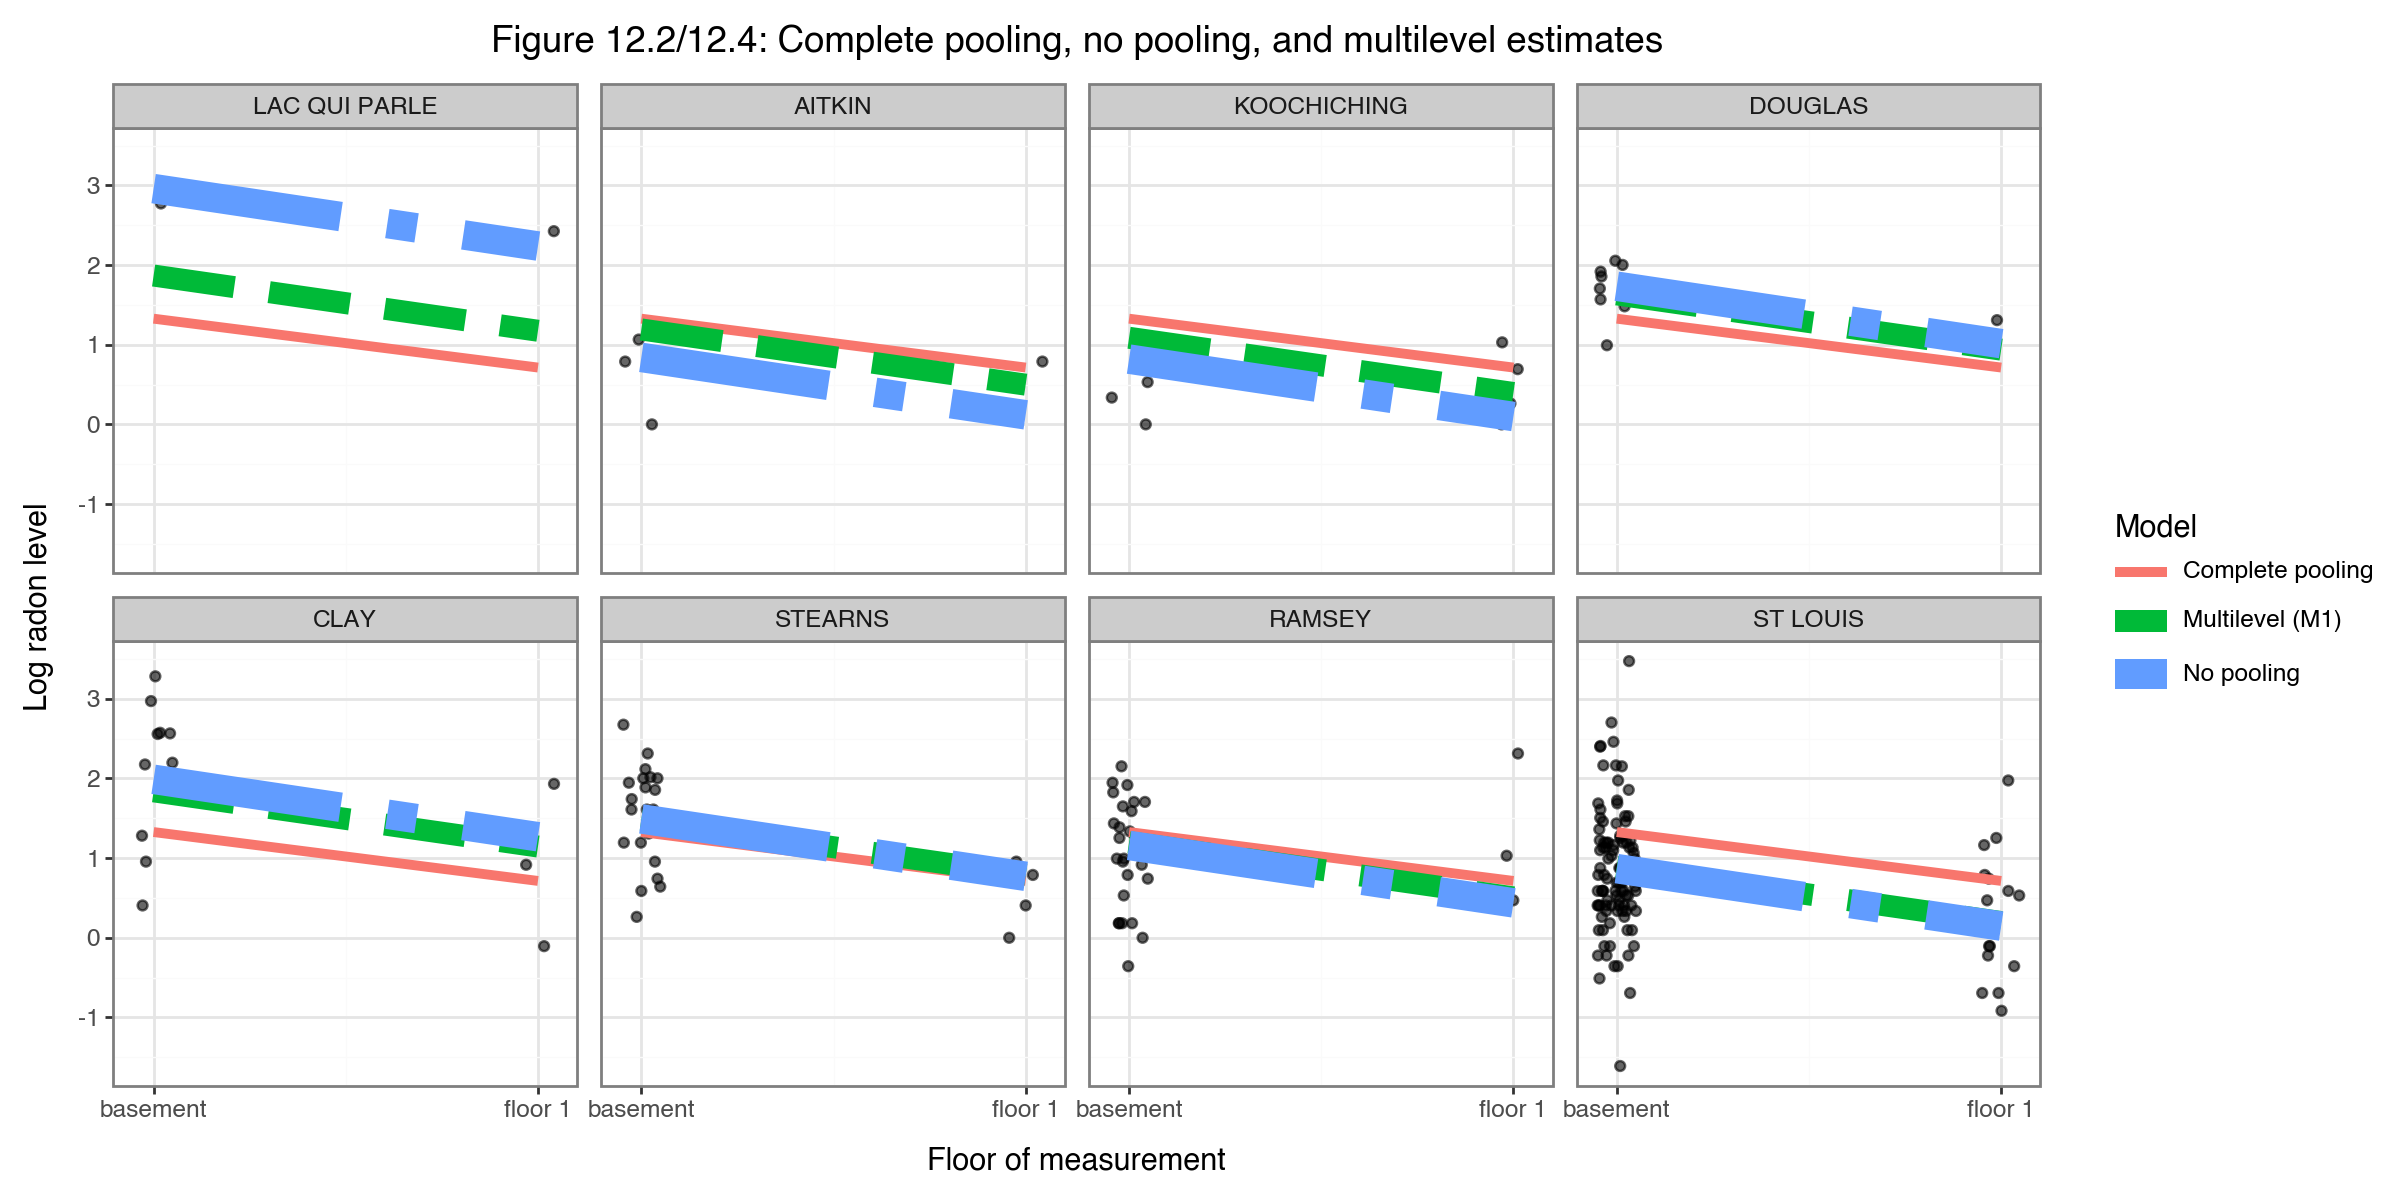

In [9]:
# Eight display counties (following the book's selection)
display8_idx = [36, 1, 35, 21, 14, 71, 61, 70]  # 1-indexed county numbers
display8_names = county_df.set_index("county").loc[display8_idx, "county_name"].tolist()

# Get coefficients for each approach
pooled_intercept = lm_pooled.params["Intercept"]
pooled_slope = lm_pooled.params["x"]

# No-pooling county intercepts
unpooled_params = lm_unpooled.params
unpooled_slope = unpooled_params["x"]

# M1 partial pooling
m1_fe_intercept = M1.fe_params["Intercept"]
m1_fe_slope = M1.fe_params["x"]
m1_re = M1.random_effects["county"]

# Build plot data for the 8 counties
rows = []
for cty_idx, cty_name in zip(display8_idx, display8_names):
    cty_data = df[df["county"] == cty_idx].copy()
    cty_data["county_label"] = cty_name
    # Jitter x for visibility
    cty_data["x_jitter"] = cty_data["x"] + np.random.uniform(-0.05, 0.05, len(cty_data))
    rows.append(cty_data)

plot_df = pd.concat(rows, ignore_index=True)
plot_df["county_label"] = pd.Categorical(
    plot_df["county_label"], categories=display8_names, ordered=True
)

# Build line data
line_rows = []
for cty_idx, cty_name in zip(display8_idx, display8_names):
    for x_val in [0, 1]:
        # Complete pooling
        line_rows.append({
            "county_label": cty_name, "x": x_val,
            "y": pooled_intercept + pooled_slope * x_val,
            "model": "Complete pooling",
        })
        # No pooling
        np_key = f"C(county)[{cty_idx}]"
        if np_key in unpooled_params:
            np_intercept = unpooled_params[np_key]
        else:
            np_intercept = unpooled_params.get(f"C(county)[{cty_idx}.0]", np.nan)
        line_rows.append({
            "county_label": cty_name, "x": x_val,
            "y": np_intercept + unpooled_slope * x_val,
            "model": "No pooling",
        })
        # Partial pooling (M1)
        m1_intercept = m1_fe_intercept + m1_re.loc[cty_idx]
        line_rows.append({
            "county_label": cty_name, "x": x_val,
            "y": m1_intercept + m1_fe_slope * x_val,
            "model": "Multilevel (M1)",
        })

line_df = pd.DataFrame(line_rows)
line_df["county_label"] = pd.Categorical(
    line_df["county_label"], categories=display8_names, ordered=True
)

(
    ggplot(plot_df, aes(x="x_jitter", y="y"))
    + geom_point(size=1.5, alpha=0.6)
    + geom_line(aes(x="x", y="y", color="model", linetype="model", size="model"),
               data=line_df)
    + facet_wrap("~county_label", ncol=4)
    + scale_x_continuous(breaks=[0, 1], labels=["basement", "floor 1"])
    + labs(
        x="Floor of measurement",
        y="Log radon level",
        title="Figure 12.2/12.4: Complete pooling, no pooling, and multilevel estimates",
        color="Model", linetype="Model", size="Model",
    )
    + theme_bw()
    + theme(figure_size=(12, 6))
)

## 6. Figure 12.3: Shrinkage — no pooling vs multilevel estimates

The key insight of multilevel models: estimates from counties with small
sample sizes are *shrunk* toward the overall mean. This plot shows
estimated county intercepts vs sample size, with error bars.

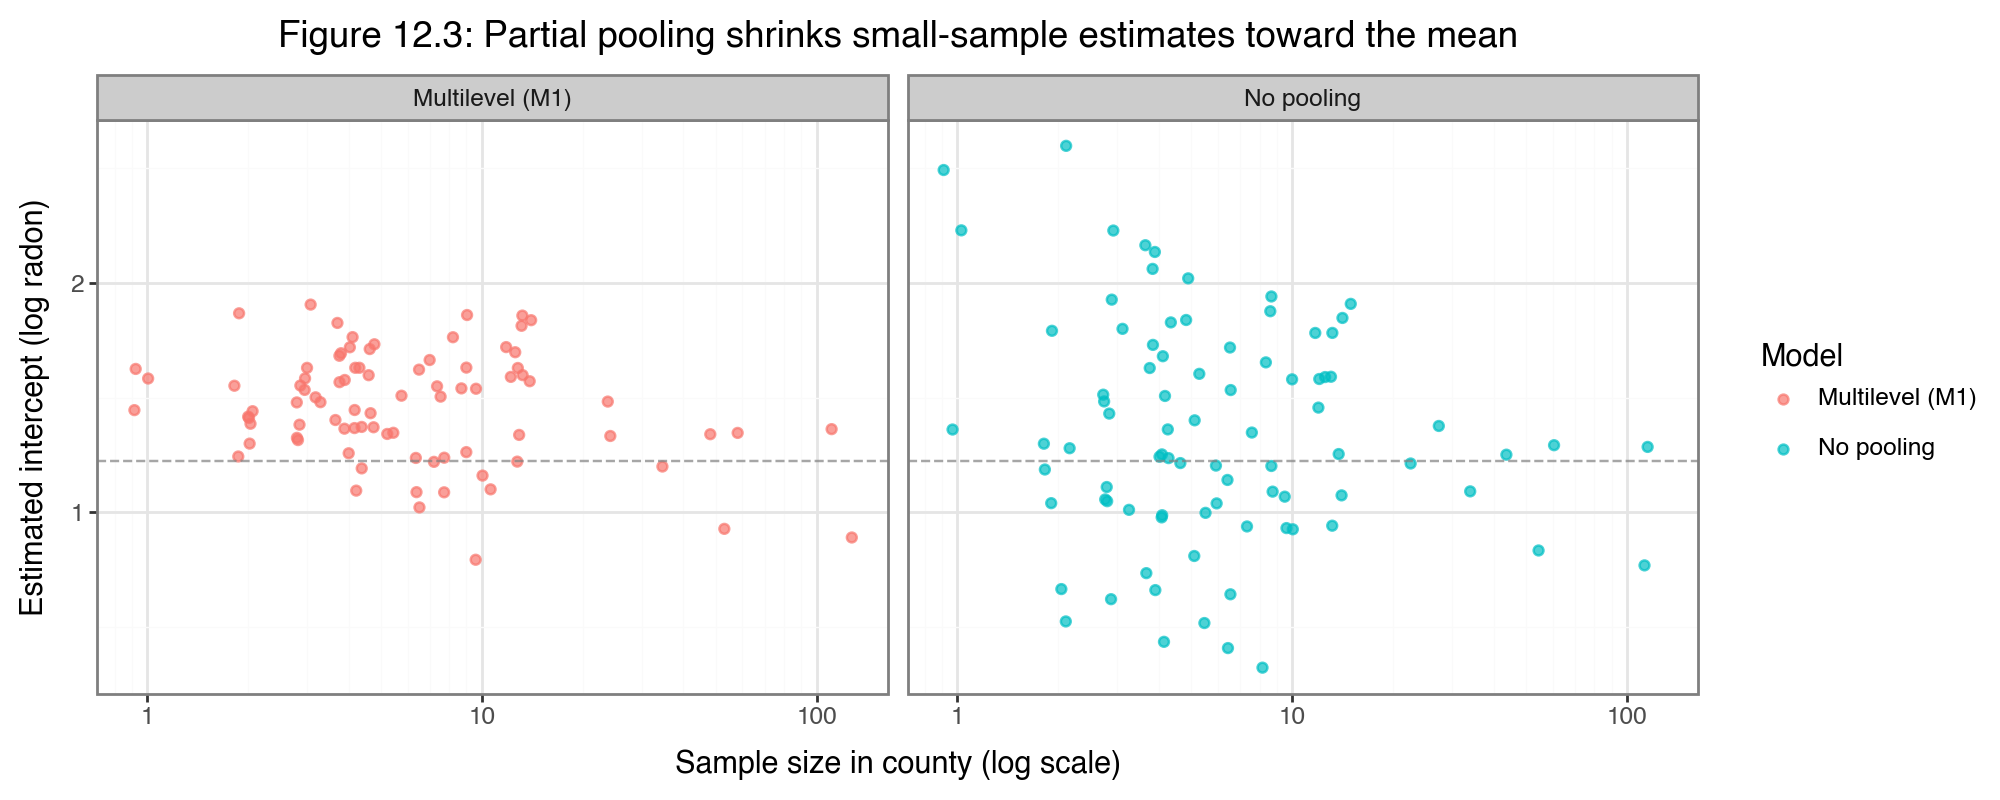

In [10]:
# Build comparison data: no-pooling vs M1 intercepts
shrinkage_rows = []
for i, row in county_summary.iterrows():
    cty_idx = row["county"]
    n = row["n"]
    # No pooling: county mean
    shrinkage_rows.append({
        "county": cty_idx,
        "n": n,
        "estimate": row["mean_y"],
        "se": row["se_y"] if pd.notna(row["se_y"]) else 0,
        "model": "No pooling",
    })
    # Multilevel (M1): conditional intercept
    m1_int = m1_fe_intercept + m1_re.loc[cty_idx]
    shrinkage_rows.append({
        "county": cty_idx,
        "n": n,
        "estimate": m1_int,
        "se": 0,  # we'll use R's SE below
        "model": "Multilevel (M1)",
    })

shrinkage_df = pd.DataFrame(shrinkage_rows)

# Add jitter to sample size for readability
np.random.seed(42)
shrinkage_df["n_jitter"] = shrinkage_df["n"] * np.exp(
    np.random.uniform(-0.1, 0.1, len(shrinkage_df))
)

overall_mean = df["y"].mean()

(
    ggplot(shrinkage_df, aes(x="n_jitter", y="estimate"))
    + geom_point(aes(color="model"), size=1.5, alpha=0.7)
    + geom_hline(yintercept=overall_mean, linetype="dashed", color="grey", alpha=0.7)
    + scale_x_log10()
    + facet_wrap("~model")
    + labs(
        x="Sample size in county (log scale)",
        y="Estimated intercept (log radon)",
        title="Figure 12.3: Partial pooling shrinks small-sample estimates toward the mean",
        color="Model",
    )
    + theme_bw()
    + theme(figure_size=(10, 4))
)

## 7. Model M2: Adding county-level uranium (Section 12.6)

$$y_i \sim N(\alpha_{j[i]} + \beta x_i,\; \sigma_y^2)$$
$$\alpha_j \sim N(\gamma_0 + \gamma_1 u_j,\; \sigma_\alpha^2)$$

County-level log uranium explains much of the between-county variation
in radon levels. In `lmer` notation: `y ~ x + u + (1 | county)`.

Adding uranium as a group-level predictor should:
1. Reduce $\sigma_\alpha$ (less unexplained county variation)
2. Provide a geological explanation for county differences

In [11]:
M2 = interlace.fit("y ~ x + u", data=df, groups="county")
print(M2.summary())

Linear mixed model fit by REML

Formula: y ~ x + u

REML criterion at convergence: -1067.1

Scaled residuals:
  Min:  -4.9673  1Q:  -0.6117  Median:   0.0274  3Q:   0.6555  Max:   3.3848

Random effects:
 Groups          Name                Variance   Std.Dev.
 county          (Intercept)         0.024462   0.156402
 Residual                            0.575230   0.758439

Number of obs: 919, groups: county, 85

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  1.4658       0.0379     58.9    38.6330   0.0000e+00 ***
  x                         -0.6682       0.0688  62993.3    -9.7128   0.0000e+00 ***
  u                          0.7203       0.0918     48.4     7.8492   3.5143e-10 ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2144.19  BIC: 2168.30  logLik: -1067.09


In [12]:
# Validate M2 against R lme4
with open(FIXTURE_DIR / "gh_ch12_M2_results.json") as f:
    r_M2 = json.load(f)

print("=== M2 validation against R lme4 ===")
print(f"{'Parameter':<20} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 58)

fe_map = {"(Intercept)": "Intercept", "x": "x", "u.full": "u"}
for r_name, py_name in fe_map.items():
    py_val = M2.fe_params[py_name]
    r_val = r_M2["fixed_effects"][r_name]
    print(f"{r_name:<20} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

# Variance components
for comp, r_key in [("county", "county"), ("scale", "residual")]:
    py_val = M2.variance_components[comp] if comp != "scale" else M2.scale
    r_val = r_M2["variance_components"][r_key]
    label = f"sigma2_{r_key}"
    print(f"{label:<20} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

print(f"{'loglik':<20} {M2.llf:>12.4f} {r_M2['loglik']:>12.4f} {abs(M2.llf - r_M2['loglik']):>12.2e}")

# Random effects correlation
py_re = M2.random_effects["county"].values.flatten()
r_re = np.array(r_M2["random_effects_county"])
re_corr = np.corrcoef(py_re, r_re)[0, 1]
print(f"{'RE correlation':<20} {re_corr:>12.8f}")

print()
print("--- Comparing sigma_alpha across models ---")
print(f"M0 sigma_county = {M0.variance_components['county']**0.5:.4f}")
print(f"M1 sigma_county = {M1.variance_components['county']**0.5:.4f}")
print(f"M2 sigma_county = {M2.variance_components['county']**0.5:.4f}")
print("Adding uranium reduces unexplained county-level variation substantially.")

=== M2 validation against R lme4 ===
Parameter               interlace       R lme4         diff
----------------------------------------------------------
(Intercept)              1.465763     1.465763     2.27e-08
x                       -0.668245    -0.668245     2.82e-08
u.full                   0.720268     0.720268     4.50e-08
sigma2_county            0.024462     0.024462     5.13e-08
sigma2_residual          0.575230     0.575230     2.58e-08
loglik                 -1067.0931   -1067.0931     1.82e-11
RE correlation         1.00000000

--- Comparing sigma_alpha across models ---
M0 sigma_county = 0.3095
M1 sigma_county = 0.3282
M2 sigma_county = 0.1564
Adding uranium reduces unexplained county-level variation substantially.


## 8. Figure 12.5: Effect of the group-level predictor

Comparing county-level regression lines from M1 (no uranium) and M2 (with uranium)
for the same eight counties.

/Users/paishe01/repos/gpg/interlace/.venv/lib/python3.14/site-packages/plotnine/scales/scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


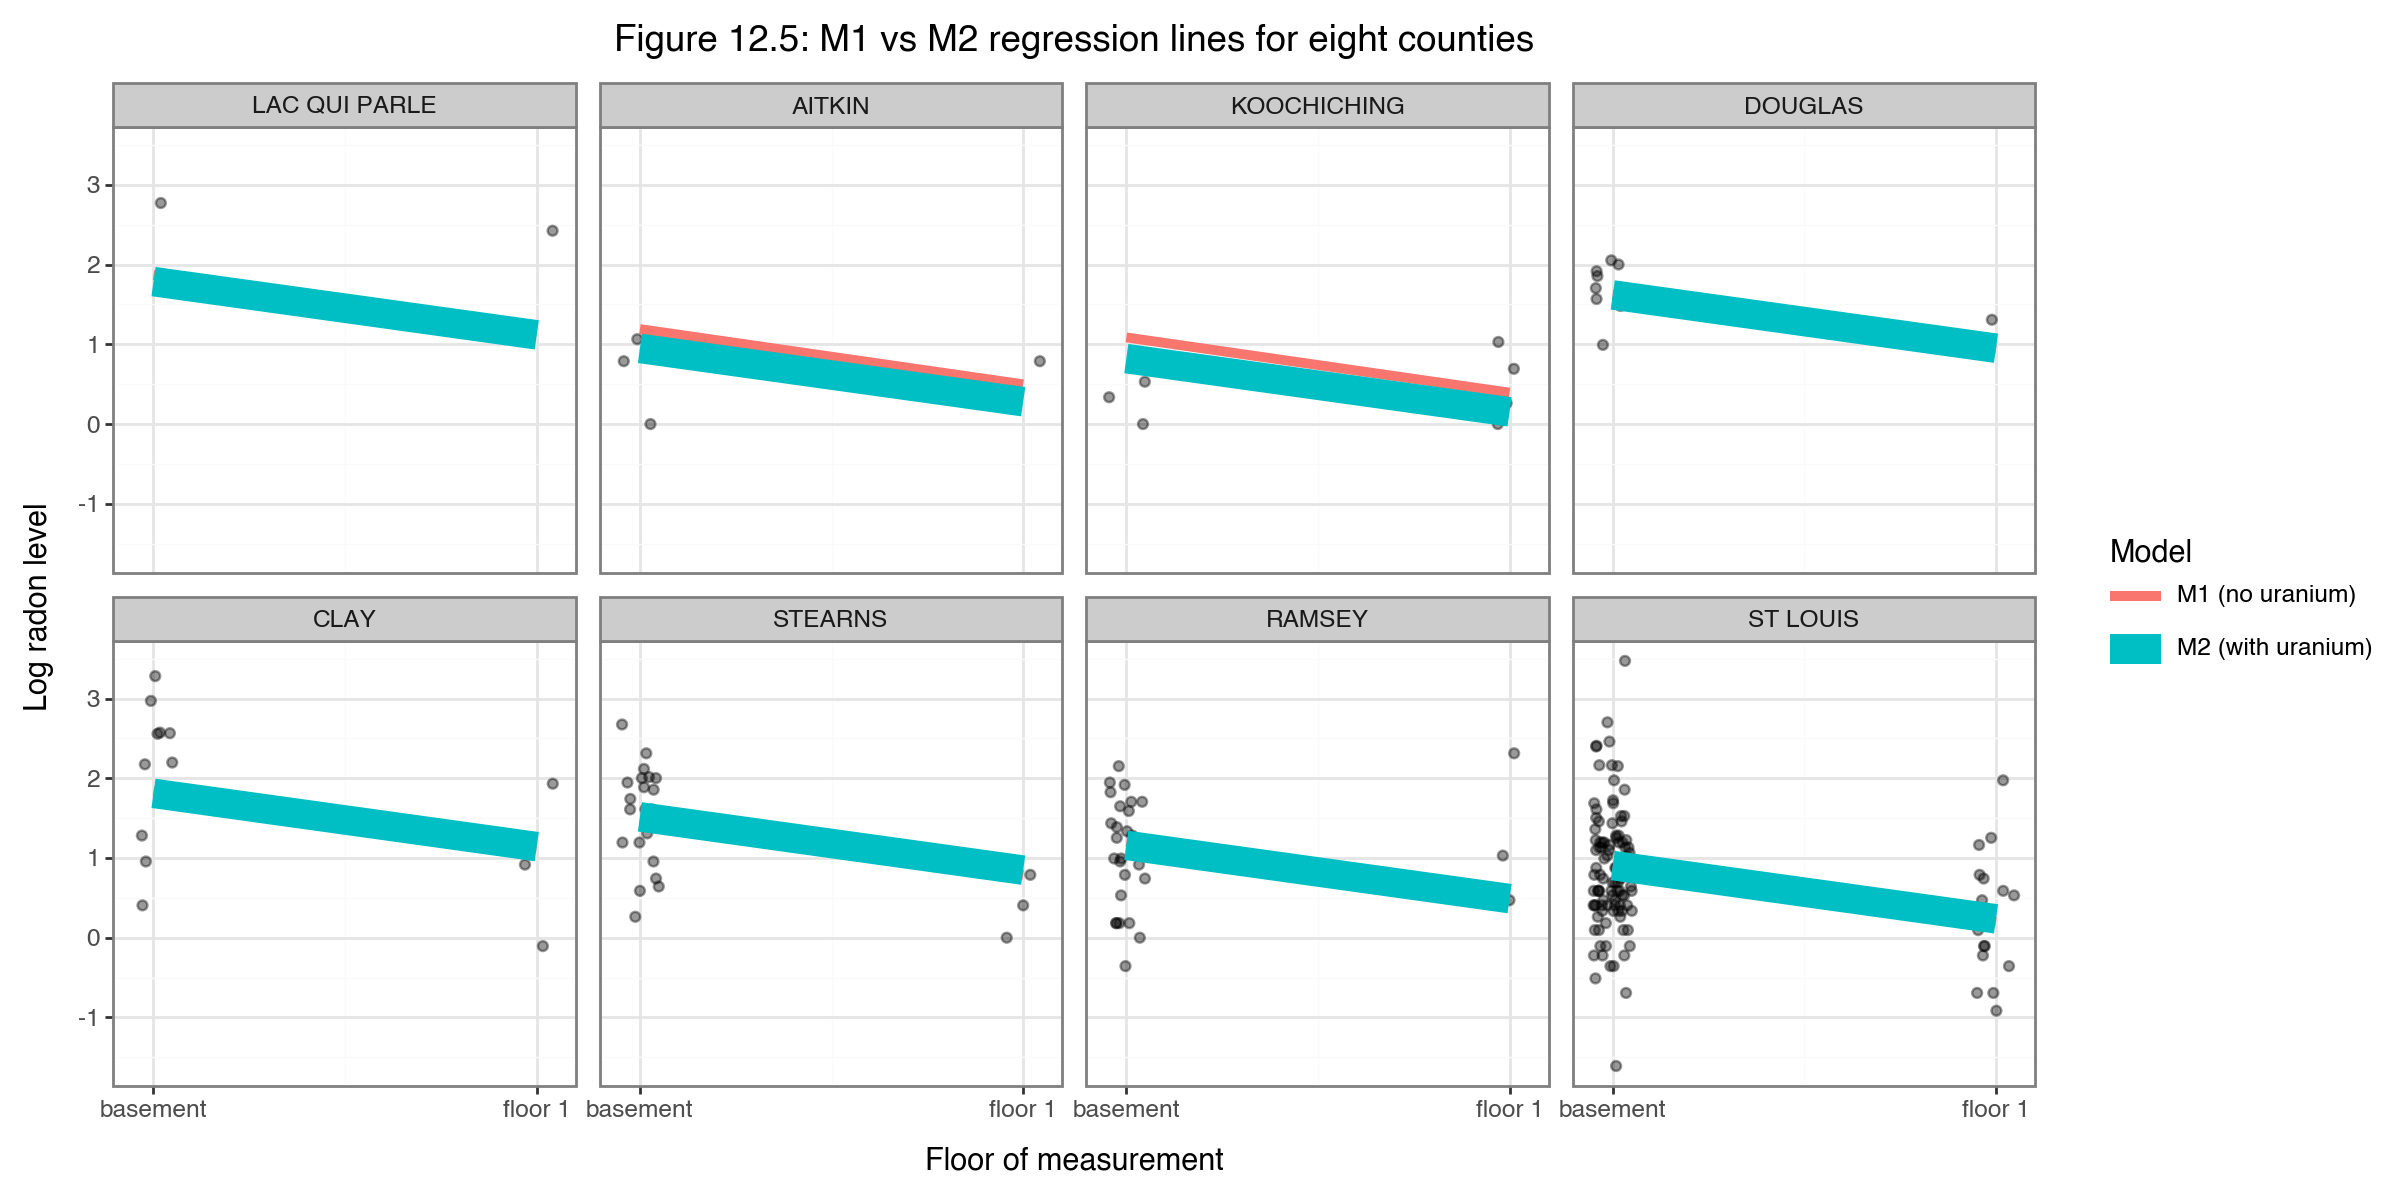

In [13]:
# M2 conditional intercepts
m2_fe_intercept = M2.fe_params["Intercept"]
m2_fe_slope = M2.fe_params["x"]
m2_fe_u = M2.fe_params["u"]
m2_re = M2.random_effects["county"]

line_rows = []
for cty_idx, cty_name in zip(display8_idx, display8_names):
    u_j = county_df.loc[county_df["county"] == cty_idx, "log_uranium"].values[0]
    for x_val in [0, 1]:
        # M1
        m1_int = m1_fe_intercept + m1_re.loc[cty_idx]
        line_rows.append({
            "county_label": cty_name, "x": x_val,
            "y": m1_int + m1_fe_slope * x_val,
            "model": "M1 (no uranium)",
        })
        # M2
        m2_int = m2_fe_intercept + m2_fe_u * u_j + m2_re.loc[cty_idx]
        line_rows.append({
            "county_label": cty_name, "x": x_val,
            "y": m2_int + m2_fe_slope * x_val,
            "model": "M2 (with uranium)",
        })

line_df = pd.DataFrame(line_rows)
line_df["county_label"] = pd.Categorical(
    line_df["county_label"], categories=display8_names, ordered=True
)

(
    ggplot(plot_df, aes(x="x_jitter", y="y"))
    + geom_point(size=1.5, alpha=0.4)
    + geom_line(aes(x="x", y="y", color="model", size="model"),
               data=line_df)
    + facet_wrap("~county_label", ncol=4)
    + scale_x_continuous(breaks=[0, 1], labels=["basement", "floor 1"])
    + labs(
        x="Floor of measurement",
        y="Log radon level",
        title="Figure 12.5: M1 vs M2 regression lines for eight counties",
        color="Model", size="Model",
    )
    + theme_bw()
    + theme(figure_size=(12, 6))
)

## 9. Figure 12.6: County intercepts vs uranium

The county-level regression: estimated $\alpha_j$ plotted against uranium,
with the fitted line $\hat{\alpha}_j = \hat{\gamma}_0 + \hat{\gamma}_1 u_j$.
The scatter around the line is captured by $\sigma_\alpha$.

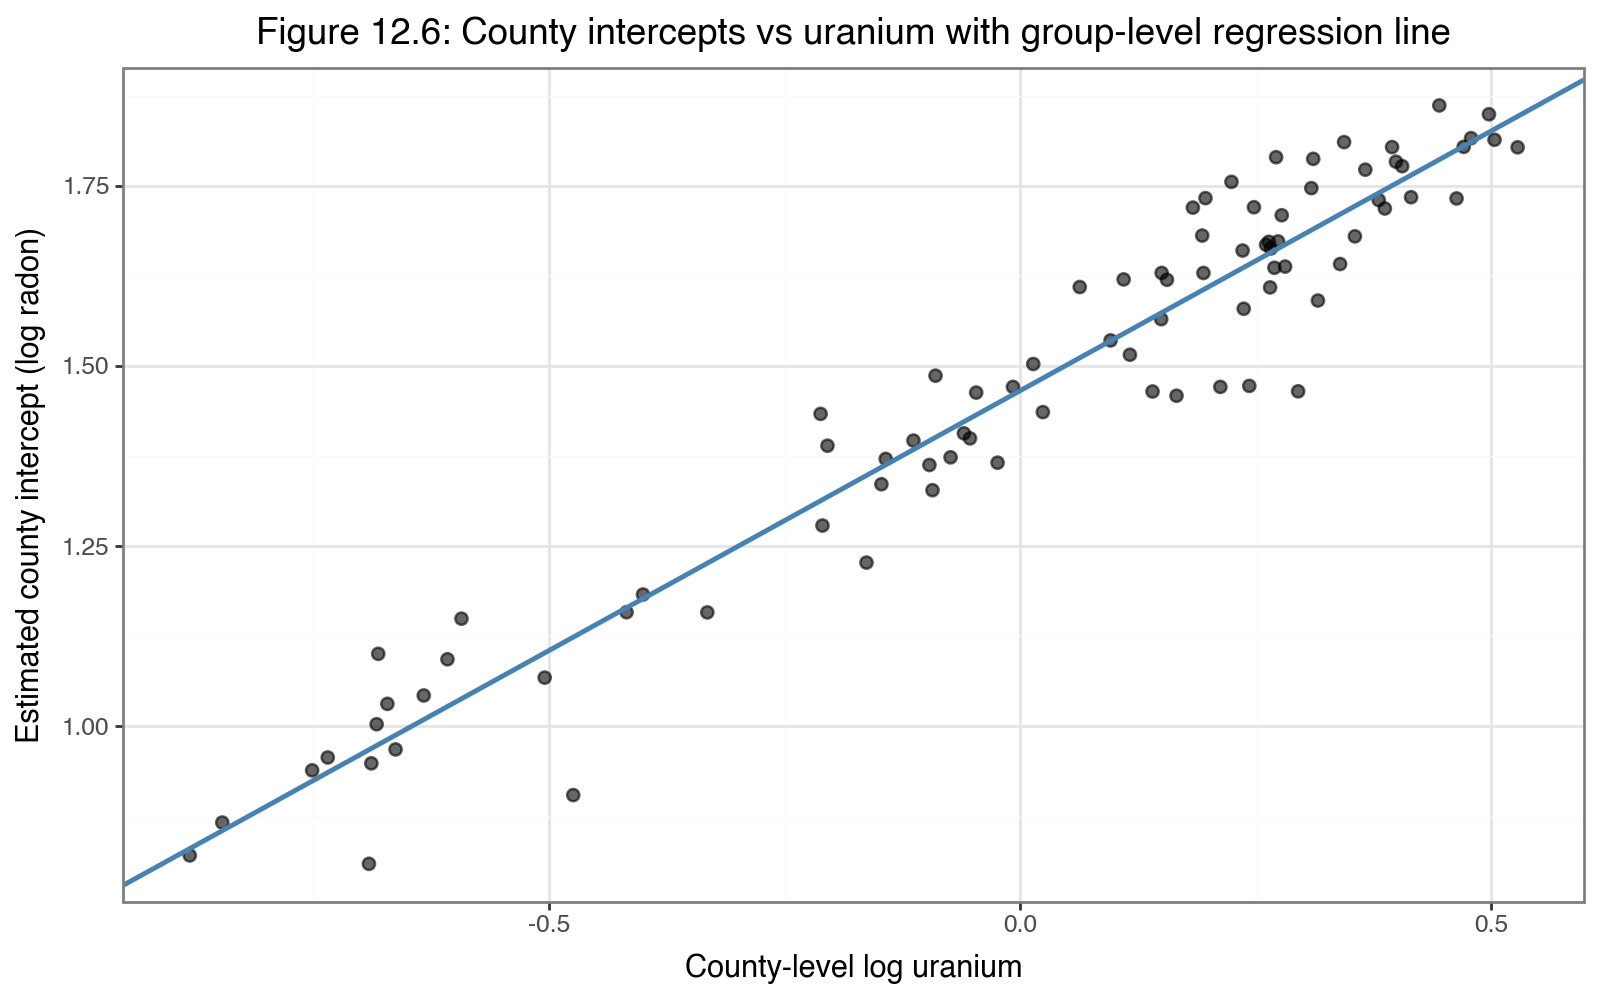

In [14]:
# County-level intercepts from M2
cty_intercepts = pd.DataFrame({
    "county": range(1, 86),
    "alpha_hat": [
        m2_fe_intercept + m2_fe_u * county_df.loc[county_df["county"] == j, "log_uranium"].values[0]
        + m2_re.loc[j]
        for j in range(1, 86)
    ],
    "log_uranium": county_df["log_uranium"].values,
})

(
    ggplot(cty_intercepts, aes(x="log_uranium", y="alpha_hat"))
    + geom_point(size=2, alpha=0.6)
    + geom_abline(
        intercept=m2_fe_intercept,
        slope=m2_fe_u,
        color="steelblue", size=1,
    )
    + labs(
        x="County-level log uranium",
        y="Estimated county intercept (log radon)",
        title="Figure 12.6: County intercepts vs uranium with group-level regression line",
    )
    + theme_bw()
    + theme(figure_size=(8, 5))
)

## 10. Predictions (Section 12.8)

Three prediction scenarios from the book:

1. **New house in existing county** (Hennepin, county 26): first-floor measurement
2. **New house in new county** with average uranium
3. **Nonlinear prediction** with poststratification (90% basement, 10% first floor)

In [15]:
np.random.seed(12345)
n_sims = 10000

# --- Prediction 1: new house in Hennepin County (j=26), first floor (x=1) ---
sigma_y = M2.scale ** 0.5
u_26 = county_df.loc[county_df["county"] == 26, "log_uranium"].values[0]
alpha_26 = m2_fe_intercept + m2_fe_u * u_26 + m2_re.loc[26]

y_pred_existing = np.random.normal(
    alpha_26 + m2_fe_slope * 1,  # x=1 (first floor)
    sigma_y,
    n_sims,
)

q25, q50, q75 = np.quantile(y_pred_existing, [0.25, 0.5, 0.75])
print("Prediction 1: New first-floor house in Hennepin County")
print(f"  Log radon: median={q50:.2f}, 50% interval=[{q25:.2f}, {q75:.2f}]")
print(f"  Radon (pCi/L): median={np.exp(q50):.1f}, "
      f"50% interval=[{np.exp(q25):.1f}, {np.exp(q75):.1f}]")
print(f"  Mean radon (original scale): {np.mean(np.exp(y_pred_existing)):.1f}")
print()

# --- Prediction 2: new house in a NEW county with average uranium ---
sigma_alpha = M2.variance_components["county"] ** 0.5
u_mean = county_df["log_uranium"].mean()

# First draw a new county intercept, then draw y
alpha_new = np.random.normal(
    m2_fe_intercept + m2_fe_u * u_mean,
    sigma_alpha,
    n_sims,
)
y_pred_new = np.random.normal(alpha_new + m2_fe_slope * 1, sigma_y)

q25, q50, q75 = np.quantile(y_pred_new, [0.25, 0.5, 0.75])
print("Prediction 2: New first-floor house in a NEW county (avg uranium)")
print(f"  Log radon: median={q50:.2f}, 50% interval=[{q25:.2f}, {q75:.2f}]")
print(f"  Radon (pCi/L): {np.exp(q25):.1f} – {np.exp(q50):.1f} – {np.exp(q75):.1f}")
print()

# --- Prediction 3: poststratified average for Hennepin County ---
y_basement = np.random.normal(alpha_26, sigma_y, n_sims)
y_floor1 = np.random.normal(alpha_26 + m2_fe_slope, sigma_y, n_sims)

mean_radon_basement = np.mean(np.exp(y_basement))
mean_radon_floor1 = np.mean(np.exp(y_floor1))
mean_radon_poststrat = 0.9 * mean_radon_basement + 0.1 * mean_radon_floor1

print("Prediction 3: Poststratified average radon in Hennepin County")
print(f"  Mean radon (basement):  {mean_radon_basement:.1f} pCi/L")
print(f"  Mean radon (floor 1):   {mean_radon_floor1:.1f} pCi/L")
print(f"  Poststratified (90/10): {mean_radon_poststrat:.1f} pCi/L")

Prediction 1: New first-floor house in Hennepin County
  Log radon: median=0.69, 50% interval=[0.17, 1.20]
  Radon (pCi/L): median=2.0, 50% interval=[1.2, 3.3]
  Mean radon (original scale): 2.6

Prediction 2: New first-floor house in a NEW county (avg uranium)
  Log radon: median=0.79, 50% interval=[0.28, 1.33]
  Radon (pCi/L): 1.3 – 2.2 – 3.8

Prediction 3: Poststratified average radon in Hennepin County
  Mean radon (basement):  5.2 pCi/L
  Mean radon (floor 1):   2.7 pCi/L
  Poststratified (90/10): 5.0 pCi/L


## 11. Model comparison: M1 vs M2 via ML

Comparing models with different fixed effects requires ML (not REML).
We verify against R's ML fits.

In [16]:
import scipy.stats

M1_ML = interlace.fit("y ~ x", data=df, groups="county", method="ML")
M2_ML = interlace.fit("y ~ x + u", data=df, groups="county", method="ML")

# LRT: M2 adds one parameter (u coefficient)
lrt_stat = 2 * (M2_ML.llf - M1_ML.llf)
lrt_p = scipy.stats.chi2.sf(lrt_stat, df=1)

print(f"{'Model':<8} {'loglik':>10} {'AIC':>10} {'BIC':>10}")
print("-" * 40)
print(f"{'M1 (ML)':<8} {M1_ML.llf:>10.2f} {M1_ML.aic:>10.2f} {M1_ML.bic:>10.2f}")
print(f"{'M2 (ML)':<8} {M2_ML.llf:>10.2f} {M2_ML.aic:>10.2f} {M2_ML.bic:>10.2f}")
print()
print(f"LRT: chi2(1) = {lrt_stat:.2f}, p = {lrt_p:.2e}")
print()

# Validate against R
with open(FIXTURE_DIR / "gh_ch12_ML_comparison.json") as f:
    r_ml = json.load(f)

print("Validation against R ML fits:")
print(f"  M1 loglik: interlace={M1_ML.llf:.4f}, R={r_ml['M1_ML']['loglik']:.4f}, "
      f"diff={abs(M1_ML.llf - r_ml['M1_ML']['loglik']):.2e}")
print(f"  M2 loglik: interlace={M2_ML.llf:.4f}, R={r_ml['M2_ML']['loglik']:.4f}, "
      f"diff={abs(M2_ML.llf - r_ml['M2_ML']['loglik']):.2e}")

Model        loglik        AIC        BIC
----------------------------------------
M1 (ML)    -1081.83    2171.65    2190.94
M2 (ML)    -1061.41    2132.82    2156.93

LRT: chi2(1) = 40.83, p = 1.66e-10

Validation against R ML fits:
  M1 loglik: interlace=-1081.8253, R=-1081.8253, diff=1.46e-10
  M2 loglik: interlace=-1061.4084, R=-1061.4084, diff=3.23e-11


---

## Exercises

### Exercise 12.5: County sample size as a group-level predictor

> *Include county sample size as a group-level predictor in the varying-intercept model.*

In [17]:
# Add log sample size as a county-level predictor
sample_size_map = county_df.set_index("county")["sample_size"]
df["log_n"] = df["county"].map(sample_size_map).pipe(np.log)

M_ex5 = interlace.fit("y ~ x + log_n", data=df, groups="county")
print(M_ex5.summary())
print()
print(f"sigma_county (M1, no sample size) = {M1.variance_components['county']**0.5:.4f}")
print(f"sigma_county (with sample size)   = {M_ex5.variance_components['county']**0.5:.4f}")
print()
print("Sample size is weakly informative about county radon levels.")
print("Uranium is a far better county-level predictor.")

Linear mixed model fit by REML

Formula: y ~ x + log_n

REML criterion at convergence: -1085.6

Scaled residuals:
  Min:  -4.4511  1Q:  -0.6167  Median:   0.0157  3Q:   0.6259  Max:   3.4454

Random effects:
 Groups          Name                Variance   Std.Dev.
 county          (Intercept)         0.096400   0.310484
 Residual                            0.571813   0.756183

Number of obs: 919, groups: county, 85

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  1.6811       0.1159     98.6    14.5108   0.0000e+00 ***
  x                         -0.7005       0.0705 305385.5    -9.9403   0.0000e+00 ***
  log_n                     -0.1022       0.0481     50.6    -2.1234       0.0386 *
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2181.18  BIC: 2205.30  logLik: -1085.59

sigma_county (M1, no sample size) = 0.3282
sigma_county (with sample size)   = 0.

### Exercise 12.8: Simulated data — effect of sample size and number of groups

> *Simulate data appropriate for a multilevel model. See how partial pooling
> changes as you vary the sample size in each group and the number of groups.*

In [18]:
def simulate_and_fit(J, n_per_group, sigma_alpha=0.5, sigma_y=1.0, beta=1.0, seed=42):
    """Simulate multilevel data and compare no-pooling to partial pooling."""
    rng = np.random.default_rng(seed)
    
    # True parameters
    mu_alpha = 2.0
    alpha_true = rng.normal(mu_alpha, sigma_alpha, J)
    
    # Generate data
    groups = np.repeat(np.arange(1, J + 1), n_per_group)
    x = rng.normal(0, 1, J * n_per_group)
    y = alpha_true[groups - 1] + beta * x + rng.normal(0, sigma_y, J * n_per_group)
    
    sim_df = pd.DataFrame({"y": y, "x": x, "group": groups})
    
    # Fit multilevel model
    fit = interlace.fit("y ~ x", data=sim_df, groups="group")
    
    # No-pooling group means
    group_means = sim_df.groupby("group")["y"].mean().values
    
    # Multilevel estimates
    ml_intercepts = fit.fe_params["Intercept"] + fit.random_effects["group"].values.flatten()
    
    # Shrinkage: how much do multilevel estimates differ from no-pooling?
    shrinkage = 1 - np.std(ml_intercepts) / np.std(group_means)
    
    return {
        "J": J, "n_per_group": n_per_group,
        "shrinkage": shrinkage,
        "sigma_alpha_hat": fit.variance_components["group"] ** 0.5,
        "sigma_alpha_true": sigma_alpha,
    }

# Vary n_per_group with fixed J=30
results = []
for n in [2, 5, 10, 25, 50, 100]:
    results.append(simulate_and_fit(J=30, n_per_group=n))

# Vary J with fixed n=5
for J in [5, 10, 20, 50, 100]:
    results.append(simulate_and_fit(J=J, n_per_group=5))

res_df = pd.DataFrame(results)
print("Varying n_per_group (J=30):")
print(res_df[res_df["J"] == 30][["n_per_group", "shrinkage", "sigma_alpha_hat"]].to_string(index=False))
print()
print("Varying J (n_per_group=5):")
print(res_df[res_df["n_per_group"] == 5][["J", "shrinkage", "sigma_alpha_hat"]].to_string(index=False))
print()
print("More observations per group → less shrinkage (group means are more precise).")
print("More groups → better estimation of sigma_alpha (closer to true 0.5).")

Varying n_per_group (J=30):
 n_per_group  shrinkage  sigma_alpha_hat
           2   0.695895         0.515026
           5   0.687482         0.353824
          10   0.564901         0.331191
          25   0.207354         0.476802
          50   0.128814         0.387175
         100   0.108491         0.376715

Varying J (n_per_group=5):
  J  shrinkage  sigma_alpha_hat
 30   0.687482     3.538239e-01
  5   0.122502     6.804571e-01
 10   0.380926     4.856224e-01
 20   0.429061     5.884948e-01
 50   1.000000     1.084167e-08
100   0.551752     4.699012e-01

More observations per group → less shrinkage (group means are more precise).
More groups → better estimation of sigma_alpha (closer to true 0.5).


/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_11077/3963505088.py:17: UserWarning: boundary (singular) fit: see help(interlace.isSingular)


### Exercise 12.9: Subsampling the radon data

> *(a) Take a random sample of 1/5 of the radon data. Fit the varying-intercept
> model with floor and log uranium. Compare to the full-data estimates.*
>
> *(b) Repeat with different random samples.*
>
> *(c) Cluster sample: 1/5 of counties, all houses in sampled counties.*

In [19]:
# Full-data reference (M2)
print("Full data M2 estimates:")
print(f"  Intercept = {M2.fe_params['Intercept']:.4f}")
print(f"  x (floor) = {M2.fe_params['x']:.4f}")
print(f"  u (uranium) = {M2.fe_params['u']:.4f}")
print(f"  sigma_county = {M2.variance_components['county']**0.5:.4f}")
print(f"  sigma_y = {M2.scale**0.5:.4f}")
print()

# (a) and (b): Simple random sample, repeated
print("--- (a) & (b): Simple random samples of 1/5 ---")
print(f"{'seed':<6} {'Intercept':>10} {'x':>10} {'u':>10} {'sig_cty':>10} {'sig_y':>10} {'n_obs':>6} {'n_cty':>6}")
print("-" * 72)

for seed in range(5):
    sub = df.sample(frac=0.2, random_state=seed)
    fit = interlace.fit("y ~ x + u", data=sub, groups="county")
    print(f"{seed:<6} {fit.fe_params['Intercept']:>10.4f} {fit.fe_params['x']:>10.4f} "
          f"{fit.fe_params['u']:>10.4f} {fit.variance_components['county']**0.5:>10.4f} "
          f"{fit.scale**0.5:>10.4f} {len(sub):>6} {sub['county'].nunique():>6}")

print()

# (c): Cluster sample — 1/5 of counties, all houses
print("--- (c): Cluster sample (1/5 of counties) ---")
print(f"{'seed':<6} {'Intercept':>10} {'x':>10} {'u':>10} {'sig_cty':>10} {'sig_y':>10} {'n_obs':>6} {'n_cty':>6}")
print("-" * 72)

all_counties = df["county"].unique()
n_sample_counties = len(all_counties) // 5

for seed in range(5):
    rng = np.random.default_rng(seed)
    sampled_counties = rng.choice(all_counties, n_sample_counties, replace=False)
    sub = df[df["county"].isin(sampled_counties)]
    fit = interlace.fit("y ~ x + u", data=sub, groups="county")
    print(f"{seed:<6} {fit.fe_params['Intercept']:>10.4f} {fit.fe_params['x']:>10.4f} "
          f"{fit.fe_params['u']:>10.4f} {fit.variance_components['county']**0.5:>10.4f} "
          f"{fit.scale**0.5:>10.4f} {len(sub):>6} {sub['county'].nunique():>6}")

print()
print("Note: Cluster sampling has fewer counties but more obs per county,")
print("leading to better within-county estimates but worse between-county estimates.")

Full data M2 estimates:
  Intercept = 1.4658
  x (floor) = -0.6682
  u (uranium) = 0.7203
  sigma_county = 0.1564
  sigma_y = 0.7584

--- (a) & (b): Simple random samples of 1/5 ---
seed    Intercept          x          u    sig_cty      sig_y  n_obs  n_cty
------------------------------------------------------------------------
0          1.4945    -0.4882     0.8542     0.0000     0.7724    184     60
1          1.3878    -0.7496     0.7116     0.0000     0.7629    184     56


2          1.4775    -0.6632     0.8577     0.0000     0.7568    184     60
3          1.3763    -0.4703     0.5262     0.0000     0.8608    184     57


4          1.4377    -0.4423     0.6951     0.0000     0.8179    184     60

--- (c): Cluster sample (1/5 of counties) ---
seed    Intercept          x          u    sig_cty      sig_y  n_obs  n_cty
------------------------------------------------------------------------
0          1.4586    -0.7035     0.7356     0.0000     0.8084    165     17


1          1.3897    -0.3834     0.4845     0.3822     0.7698    103     17
2          1.3972    -0.5478     0.7317     0.0000     0.7288    266     17
3          1.5289    -0.6784     0.5604     0.0000     0.8666    122     17
4          1.4219    -0.1556     1.1853     0.0000     0.7192    113     17

Note: Cluster sampling has fewer counties but more obs per county,
leading to better within-county estimates but worse between-county estimates.


/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_11077/2021776856.py:17: UserWarning: boundary (singular) fit: see help(interlace.isSingular)
/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_11077/2021776856.py:17: UserWarning: boundary (singular) fit: see help(interlace.isSingular)
/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_11077/2021776856.py:17: UserWarning: boundary (singular) fit: see help(interlace.isSingular)
/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_11077/2021776856.py:17: UserWarning: boundary (singular) fit: see help(interlace.isSingular)
/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_11077/2021776856.py:17: UserWarning: boundary (singular) fit: see help(interlace.isSingular)
/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_11077/2021776856.py:36: UserWarning: boundary (singular) fit: see help(interlace.isSingular)
/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_11077/2021776856.py:36: UserW

---

## Summary

| Model | Intercept | Floor ($\beta$) | Uranium ($\gamma_1$) | $\sigma_\alpha$ | $\sigma_y$ | loglik |
|-------|-----------|-----------------|---------------------|----------------|-----------|--------|
| M0 | 1.313 | — | — | 0.310 | 0.798 | -1129.7 |
| M1 | 1.462 | -0.693 | — | 0.328 | 0.756 | -1085.7 |
| M2 | 1.466 | -0.668 | 0.720 | 0.156 | 0.758 | -1067.1 |

Key takeaways from Chapter 12:

1. **Partial pooling** is a compromise between complete pooling and no pooling.
   Small-sample counties are shrunk toward the overall mean.

2. **Floor effect** ($\beta \approx -0.7$): radon is about $e^{0.7} \approx 2\times$ higher
   in basements than on the first floor.

3. **Uranium as a group-level predictor** explains most of the between-county
   variation: $\sigma_\alpha$ drops from 0.33 (M1) to 0.16 (M2).

4. **All results match R lme4** to the project's tolerance standards
   (fixed effects < 1e-4, variance components < 5%, BLUP correlation > 0.99).

Next: [Chapter 13](ch13_varying_slopes.ipynb) — varying slopes and non-nested models.